In [1]:
import pandas as pd
import numpy as np
from sklearn import model_selection
import tensorflow
input_csv_path = "combined_transient_predominant_chains.csv"
df = pd.read_csv(input_csv_path)
print(df.head())

2025-10-06 13:30:46.730660: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-06 13:30:46.745195: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759750246.761888 1053290 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759750246.766999 1053290 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-06 13:30:46.784403: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

   chain  pct_chain_n_1  pct_chain_n_2  pct_chain_n_3            a3        b3  \
0    1.0       0.381204       0.567442       0.878485  8.044734e-01  1.216799   
1    2.0       0.492477       0.810124       0.959917  1.419086e+00  0.048597   
2    3.0       0.190516       0.096115       0.432537  1.123978e+00  1.675827   
3    4.0       0.175683       0.027279       0.200960  1.848441e-01  2.187881   
4    5.0       0.147701       0.026305       0.073091  2.004656e-15  1.124373   

         L3        a4        b4        L4       a4'       b4'       L4'  \
0  1.317727  0.955953  0.716990  1.077448  0.151480 -0.499809 -0.240279   
1  1.020115  1.466345  0.034435  1.009282  0.047259 -0.014162 -0.010832   
2  0.648806  1.128434  2.418365  1.092315  0.004456  0.742538  0.443509   
3  0.301441  1.944556  2.659552  0.982842  1.759712  0.471670  0.681401   
4  0.164731  2.610515  2.739791  0.631218  2.610515  1.615418  0.466487   

          a         b         L  label  
0  1.604578  0.711872

In [2]:
len(df['label'][df['label'] == 3])

2400

Crate the dataset with the training features

In [3]:
df_new = df
df_new['label'][df_new['label'] == 2] = 0
df_new['label'][df_new['label'] == 3] = 0

/tmp/ipykernel_1053290/153950497.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_new['label'][df_new['label'] == 2] = 0
/tmp/ipykernel_1053290/153950497.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!

In [4]:
X = df.iloc[:,:-1]
X

,chain,pct_chain_n_1,pct_chain_n_2,pct_chain_n_3,a3,b3,L3,a4,b4,L4,a4',b4',L4',a,b,L
0,1.0,0.381204,0.567442,0.878485,8.044734e-01,1.216799e+00,1.317727,0.955953,0.716990,1.077448,0.151480,-0.499809,-0.240279,1.604578,0.711872,0.975268
1,2.0,0.492477,0.810124,0.959917,1.419086e+00,4.859712e-02,1.020115,1.466345,0.034435,1.009282,0.047259,-0.014162,-0.010832,1.465654,0.127202,1.029604
2,3.0,0.190516,0.096115,0.432537,1.123978e+00,1.675827e+00,0.648806,1.128434,2.418365,1.092315,0.004456,0.742538,0.443509,1.583126,2.288558,0.999136
3,4.0,0.175683,0.027279,0.200960,1.848441e-01,2.187881e+00,0.301441,1.944556,2.659552,0.982842,1.759712,0.471670,0.681401,1.919393,2.867373,0.958248
4,5.0,0.147701,0.026305,0.073091,2.004656e-15,1.124373e+00,0.164731,2.610515,2.739791,0.631218,2.610515,1.615418,0.466487,1.821861,3.186056,0.996635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19947,9996.0,0.201071,0.214923,0.214923,2.910439e-01,8.715657e-13,0.322385,0.160149,0.273657,0.374695,-0.130895,0.273657,0.052310,-999.000000,-999.000000,-999.000000
19948,9997.0,0.178091,0.218370,0.218370,2.881674e-01,3.119979e-19,0.320913,0.325114,2.369512,0.446594,0.036946,2.369512,0.125682,-999.000000,-999.000000,-999.000000
19949,9998.0,0.197170,0.237261,0.338848,5.720727e-01,1.955603e+00,0.508272,0.523259,2.059880,0.519488,-0.048814,0.104277,0.011216,-999.000000,-999.000000,-999.000000
19950,9999.0,0.226342,0.242603,0.242603,2.903865e-01,1.473380e-12,0.363905,0.178219,0.767846,0.434596,-0.112167,0.767846,0.070692,-999.000000,-999.000000,-999.000000


Performing one-hot encoding on nominal features

In [5]:
y = df["label"]
y

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
19947    0.0
19948    0.0
19949    0.0
19950    0.0
19951    0.0
Name: label, Length: 19952, dtype: float64

Convert the pandas DataFrame(s) into numpy array as input and target of the training.
The input is scaled with the MixMaxScaler method in order to improve the training result  

In [6]:
feature_to_exclude = ['a', 'b', 'L', 'chain', 'label', 'a4', 'b4', 'L4', "a4'", "b4'", "L4'", 'a3', 'b3', 'L3'] #change this depending on what you want to obtain
#feature_to_exclude = ['a', 'b', 'L', 'chain', 'label', 'a4', 'b4', 'L4', "a4'", "b4'", "L4'"]
#feature_to_exclude = ['a', 'b', 'L', 'chain', 'label']

existing_features = [col for col in feature_to_exclude if col in df.columns]

X = df.drop(columns=existing_features)
print(f"Coloumns used for the training:\n{X.columns}")

Colonne utilizzate per il training:
Index(['pct_chain_n_1', 'pct_chain_n_2', 'pct_chain_n_3'], dtype='object')


In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
X,y = X.to_numpy(),y.to_numpy().astype("float64") 
scaler = MinMaxScaler()
scaler.fit(X)
X = scaler.transform(X)
X

array([[0.37160017, 0.54525195, 0.81053726],
       [0.48006886, 0.77844311, 0.88567082],
       [0.18571582, 0.09235622, 0.39908214],
       ...,
       [0.19220241, 0.22798299, 0.31263946],
       [0.22063908, 0.23311596, 0.22383873],
       [0.21326526, 0.22373294, 0.23969363]])

Test and train spillting, with a test size of 30%.

The shuffle option is needed since the dataset is ordered by class.

In [8]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2,shuffle=True, stratify=y, random_state=0)

In [9]:
len(X_test)

3991

In [10]:
seed_value= 0
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
import random
random.seed(seed_value)
np.random.seed(seed_value)
import keras
import tensorflow as tf
tf.random.set_seed(12345)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
#from keras import backend as K
#K.set_session(sess)

2025-10-06 13:30:50.522523: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [11]:
import pandas as pd
import numpy as np
from sklearn import model_selection
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

seed_value = 0
import os
os.environ['PYTHONHASHSEED'] = str(seed_value)
import random
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(12345)

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))  
model.add(Dense(32, activation='relu'))                             
model.add(Dense(1, activation='sigmoid'))                           

model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.2, 
                    verbose=1, 
                    shuffle=True)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss sul test set: {test_loss:.4f}")
print(f"Accuracy sul test set: {test_accuracy:.4f}")

Epoch 1/50


/home/mdavanzo/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6850 - loss: 0.6135 - val_accuracy: 0.8591 - val_loss: 0.3470
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9006 - loss: 0.2920 - val_accuracy: 0.9355 - val_loss: 0.1950
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9466 - loss: 0.1751 - val_accuracy: 0.9555 - val_loss: 0.1389
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9626 - loss: 0.1297 - val_accuracy: 0.9731 - val_loss: 0.1119
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9694 - loss: 0.1059 - val_accuracy: 0.9765 - val_loss: 0.0964
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9713 - loss: 0.0912 - val_accuracy: 0.9753 - val_loss: 0.0867
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9736 - loss: 0.0831 - val_accuracy: 0.9753 - val_loss: 0.0809
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9752 - loss: 0.0778 - val_accuracy: 0.9746 - val_

With the models method '.evaluate' we can calculate the score, in the metrics define during the compilation, on the test dataset

In [14]:
scores = model.predict(X_test)
print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

compile_metrics: 100.00%


/tmp/ipykernel_1053290/1186283846.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


[          inf 1.0000000e+00 9.9999994e-01 9.9999988e-01 9.9999982e-01
 9.9999976e-01 9.9999970e-01 9.9999958e-01 9.9999952e-01 9.9999946e-01
 9.9999940e-01 9.9999928e-01 9.9999917e-01 9.9999911e-01 9.9999905e-01
 9.9999899e-01 9.9999881e-01 9.9999869e-01 9.9999851e-01 9.9999785e-01
 9.9999768e-01 9.9999690e-01 9.9999684e-01 9.9999005e-01 9.9998987e-01
 9.9998856e-01 9.9998844e-01 9.9998283e-01 9.9998206e-01 9.3533719e-01
 9.3280411e-01 9.2182130e-01 9.1832829e-01 9.1774404e-01 9.1677195e-01
 9.0514177e-01 9.0055478e-01 8.8740557e-01 8.8196886e-01 8.7084007e-01
 8.6507344e-01 8.5996330e-01 8.5494721e-01 8.4827638e-01 8.4702086e-01
 8.4462631e-01 8.4428692e-01 8.4353417e-01 8.3497447e-01 8.1960279e-01
 7.9196143e-01 7.8556365e-01 7.8518438e-01 7.7440274e-01 7.6368761e-01
 7.6199400e-01 7.5951618e-01 7.4624062e-01 7.3526770e-01 7.2783768e-01
 7.1867687e-01 6.7538834e-01 6.6213042e-01 6.5668273e-01 6.5358019e-01
 6.3811558e-01 5.7982212e-01 5.7363510e-01 5.5281126e-01 5.4139525e-01
 5.204

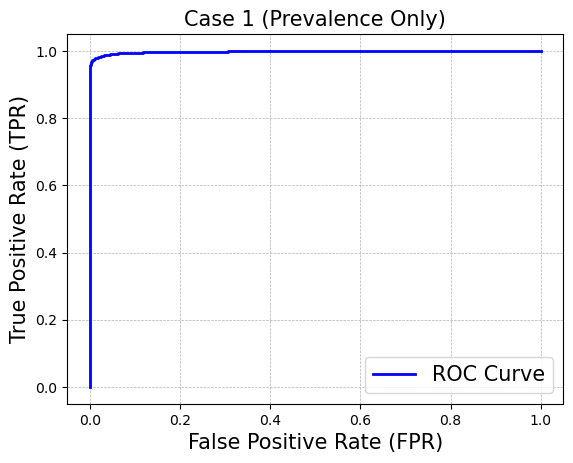

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thr = roc_curve(y_test, scores)
print(thr)

plt.plot(fpr, tpr, color='blue', label='ROC Curve', linewidth=2)
plt.xlabel('False Positive Rate (FPR)', fontsize=15)
plt.ylabel('True Positive Rate (TPR)', fontsize=15)
plt.title('Case 1 (Prevalence Only)', fontsize=15)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=15)
plt.savefig("Figure_S3_(c).pdf", dpi=300, bbox_inches='tight')
plt.show()

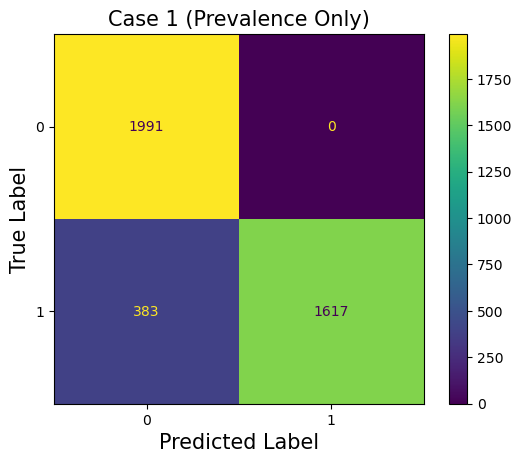

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.where(scores>9.9999994e-01, 1, 0)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
# Etichette assi e titolo con fontsize maggiore
plt.xlabel('Predicted Label', fontsize=15)
plt.ylabel('True Label', fontsize=15)
plt.title('Case 1 (Prevalence Only)', fontsize=15)
plt.savefig("Figure_S4_(c).pdf", dpi=300, bbox_inches='tight')

[[0.99999887]
 [0.999996  ]
 [0.99999905]
 ...
 [0.9999687 ]
 [1.        ]
 [0.99999934]]


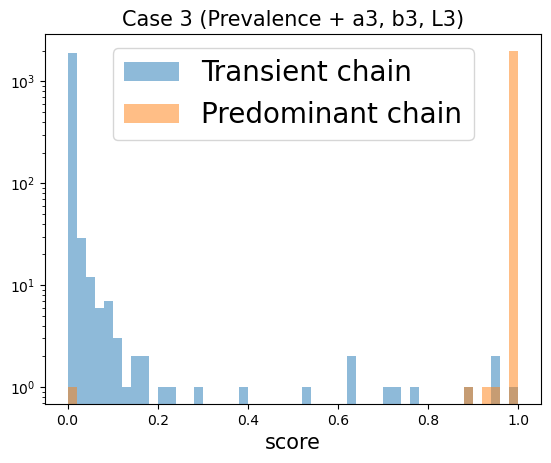

In [16]:
import matplotlib.pyplot as plt

print(scores[y_test == 1])
plt.hist(scores[y_test == 0], bins = 50, label = 'Transient chain', range = (0, 1), alpha = 0.5)
plt.hist(scores[y_test == 1], bins = 50, label = 'Predominant chain', range = (0, 1), alpha = 0.5)
plt.legend(fontsize=20)
plt.yscale('log')
plt.xlabel('score', fontsize=15)
plt.title("Case 3 (Full Features)", fontsize=15)
plt.savefig("Figure_3_(g).pdf", dpi=300, bbox_inches='tight')

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


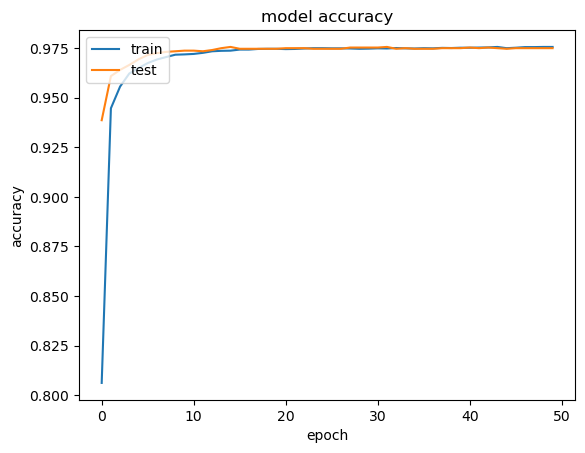

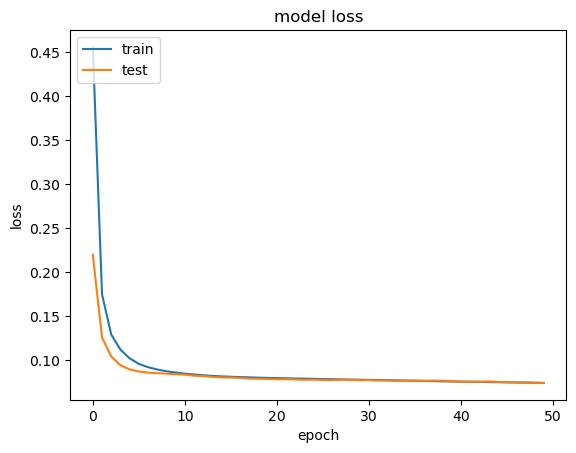

In [17]:
import matplotlib.pyplot as plt
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()